In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import src.comp.gc as gc_module
import os
import glob
import pandas as pd
from joblib import Parallel, delayed
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from typing import List, Optional
from difflib import SequenceMatcher
from pathlib import Path
import scipy
import matplotlib.patches as mpatches

In [2]:
def sync_file_lists(
    list1: List[Path], list2: List[Path]
) -> List[Optional[Path]]:
    """
    Syncs two lists of Paths based on the longest matching substring.

    For each path in list1, this function finds the path in list2 that
    shares the longest common substring with it. The result is a new list,
    ordered according to list1, containing the best-matching paths from list2.

    Args:
        list1: The reference list of Path objects. The order of this list is
               preserved in the output.
        list2: The list of Path objects to search for matches.

    Returns:
        A new list of Path objects. Each element at index `i` is the best
        match from `list2` for the element at `list1[i]`. If `list2` is empty
        or no match is found for an item, the corresponding entry will be None.
    """
    synced_list: List[Optional[Path]] = []

    # If list2 is empty, there can be no matches.
    if not list2:
        return [None] * len(list1)

    # For each path in the reference list...
    for path1 in list1:
        str_path1 = str(path1)
        best_match_path = None
        max_match_size = -1

        # ...find the best match from the second list.
        for path2 in list2:
            str_path2 = str(path2)
            
            # Use SequenceMatcher to find the longest contiguous matching block.
            matcher = SequenceMatcher(a=str_path1, b=str_path2, autojunk=False)
            match = matcher.find_longest_match()

            if match.size > max_match_size:
                max_match_size = match.size
                best_match_path = path2
        
        synced_list.append(best_match_path)

    return synced_list

In [3]:
cris_metadata = pd.read_csv("accessory_files/cris_metadata.csv")
pon_file_names = []
for i in range(22, 70):
    name = f"EE879{i:02d}"
    pon_file_names.append(name)

pon_file_names = cris_metadata[cris_metadata['disease'] == 'Healthy'].iloc[2:50]['ID'].tolist()  # 48 samples, since the first two are not cfDNA
healthy_file_names = cris_metadata[cris_metadata['disease'] == 'Healthy'].iloc[50:]['ID'].tolist()  # Remaining healthy samples
cancer_file_names = cris_metadata[(cris_metadata['disease'] == 'Breast cancer') | (cris_metadata['disease'] == 'Colorectal cancer')]['ID'].tolist()

# Supplementary data
cris_supplement = pd.read_excel('accessory_files/cristiano_metadata.xlsx', skiprows=[0])

pon_supp_names = cris_metadata[cris_metadata['disease'] == 'Healthy']['sample_name'].iloc[2:50].values.tolist()
cris_supplement_pon = cris_supplement[cris_supplement['Patient'].isin(pon_supp_names)]
healthy_supp_names = cris_metadata[cris_metadata['disease'] == 'Healthy']['sample_name'].iloc[50:].values.tolist()
cris_supplement_healthy = cris_supplement[cris_supplement['Patient'].isin(healthy_supp_names)]
cancer_supp_names = cris_metadata[(cris_metadata['ID'].isin(cancer_file_names))]['sample_name'].values.tolist()
cris_supplement_cancer = cris_supplement[cris_supplement['Patient'].isin(cancer_supp_names)]
cris_supplement_pon.shape, cris_supplement_healthy.shape, cris_supplement_cancer.shape


((48, 18), (212, 18), (81, 18))

In [4]:
# --- This part of your code remains unchanged ---
blacklist = pd.read_csv("accessory_files/hg38_GCcorrection_ExclusionList.merged.sorted.bed", sep='\t', header=None, names=['chrom', 'start', 'end', 'desc'])
# If centromer in desc, keep that row
blacklist = blacklist[blacklist['desc'].str.contains('centromer')]

def get_hg38_chrom_lengths():
    """Returns a dictionary of hg38 chromosome lengths for major chromosomes."""
    return {
        'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
        'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
        'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
        'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
        'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
        'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285,
        'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983,
        'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415
    }

def add_cumulative_position(df, chrom_lengths):
    """Adds a 'cumulative_pos' column to the dataframe for genome-wide plotting."""
    df['chrom'] = df['chrom'].astype(str)
    if not df['chrom'].iloc[0].startswith('chr'):
        df['chrom'] = 'chr' + df['chrom']
    
    chrom_offsets = {}
    current_offset = 0
    sorted_chroms = sorted(chrom_lengths.keys(), key=lambda x: int(x[3:]) if x[3:].isdigit() else ord(x[3:]))
    
    for chrom in sorted_chroms:
        chrom_offsets[chrom] = current_offset
        current_offset += chrom_lengths.get(chrom, 0)

    df['cumulative_pos'] = df.apply(
        lambda row: chrom_offsets.get(row['chrom'], 0) + row['start'], axis=1
    )
    return df, chrom_offsets

# --- This is where the main changes are ---

def process_file(file_path, features_to_agg):
    """
    Worker function: reads a single CSV file and extracts feature columns.
    This function will be executed in parallel for each file.
    """
    df = pd.read_csv(file_path)
    feature_data = {}
    for feature in features_to_agg:
        # Apply the same logic as in the original code
        if feature == 'mds':
            feature_data[feature] = df[feature].values * -1
        else:
            feature_data[feature] = df[feature].values
    return feature_data

def aggregate_data_from_folder(folder_path, features_to_agg, file_filter=None):
    """
    Loads all CSV files from a folder in parallel, aggregates specified features,
    and returns a dataframe with mean and std for each bin.
    """
    all_files = sorted(glob.glob(os.path.join(folder_path, '*tsv_BIN.csv')))

    if not all_files:
        return None
    
    if file_filter:
        all_files = sync_file_lists(file_filter, [Path(f) for f in all_files])
        print(f"Filtered to {len(all_files)} files after applying the filter.")

    # Use the first file to get the genomic coordinates template
    template_df = pd.read_csv(all_files[0])
    
    # Determine the number of CPU cores to use for parallel processing
    num_cores = multiprocessing.cpu_count()
    print(f"Loading {len(all_files)} samples from {folder_path} using {num_cores} cores...")

    # Use joblib to process files in parallel
    # `delayed` wraps the function call, and `Parallel` executes them
    results = Parallel(n_jobs=num_cores)(
        delayed(process_file)(f, features_to_agg) for f in tqdm(all_files)
    )
    
    # Reorganize the parallel results back into the original `data_list` structure
    data_list = {feature: [] for feature in features_to_agg}
    for item in results:
        for feature in features_to_agg:
            data_list[feature].append(item[feature])
            
    # Create the aggregated dataframe (this logic is unchanged)
    agg_df = template_df[['chrom', 'start', 'end']].copy()
    
    print("\nCalculating mean and standard deviation...")
    for feature in tqdm(features_to_agg):
        # Stack the arrays for efficient calculation
        feature_matrix = np.vstack(data_list[feature])
        print("Feature", feature, feature_matrix.shape)
        agg_df[f'{feature}_mean'] = np.nanmean(feature_matrix, axis=0)
        agg_df[f'{feature}_std'] = np.nanstd(feature_matrix, axis=0)

    return agg_df

# =================================================================================
# --- ✨ NEW FUNCTION: Load a single feature from all files in parallel ---
# =================================================================================

def _worker_load_feature(file_path, feature_name):
    """
    A simple worker function for parallel execution.
    Reads one CSV and returns just the one specified feature column as a NumPy array.
    """
    try:
        df = pd.read_csv(file_path, usecols=[feature_name])
        return df[feature_name].values
    except Exception as e:
        print(f"Error processing file {os.path.basename(file_path)}: {e}")
        return None

def load_feature_in_parallel(folder_path, feature_name, file_filter=None):
    """
    Loads a single feature from all matching CSV files in a folder in parallel.

    The key to maintaining order is sorting the file paths *before* parallelizing.
    The final array will have columns corresponding to the alphabetically sorted file names.

    Args:
        folder_path (str): The path to the directory containing the CSV files.
        feature_name (str): The name of the column (feature) to extract.
        file_filter (list, optional): A list of IDs to filter file names.

    Returns:
        np.ndarray: A 2D NumPy array of shape (n_samples, n_features), which in this
                    context is (number_of_bins, number_of_files). Returns None if no
                    files are found.
    """
    print(f"--- Loading feature '{feature_name}' in parallel ---")
    
    # 1. Find all relevant files and SORT them. This is critical for order.
    all_files = sorted(glob.glob(os.path.join(folder_path, '*tsv_BIN.csv')))
    if not all_files:
        print(f"Warning: No '*tsv_BIN.csv' files found in {folder_path}")
        return None

    if file_filter:
        all_files = sync_file_lists(file_filter, [Path(f) for f in all_files])
        print(f"Filtered to {len(all_files)} files after applying the filter.")

    # 3. Use ProcessPoolExecutor to load files in parallel.
    # It's a modern and clean way to manage a pool of processes.
    with ProcessPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
        # The `executor.map` function applies the worker to each file path.
        # Importantly, it returns the results in the same order as the input.
        results = list(tqdm(executor.map(_worker_load_feature, all_files, [feature_name]*len(all_files)), total=len(all_files)))

    # Filter out any potential `None` results from failed file reads
    valid_results = [res for res in results if res is not None]
    if not valid_results:
        print("Error: Could not successfully load the feature from any file.")
        return None

    # 4. Stack the resulting 1D arrays into a single 2D array.
    # np.stack with axis=1 makes each file's data a new column.
    # The shape will be (rows_per_file, num_files).
    final_array = np.stack(valid_results, axis=1).T
    
    print(f"Successfully created array of shape: {final_array.shape}")
    return final_array

# --- Main execution block remains unchanged ---

# --- IMPORTANT ---
# Update this to the base directory containing your resolution folders
base_path = './extracted_features/' 

resolutions = ['100kb']
features_to_aggregate = ['fslr', 'fslr_coverage', 'griffin_diff', 'rcov', 'mwh', 'absolute_fragment_counts','relative_fragment_counts','absolute_short_fragments','absolute_long_fragments','mean_coverage','mean_coverage_short','mean_coverage_long','coverage_spread','gc_content','mean_fragment_gc_content','mean_fragment_gc_content_short','mean_fragment_gc_content_long','mds']
# features_to_aggregate += np.arange(100, 221, 1).astype(str).tolist()  # Adding '100' to '220' as strings

chrom_lengths = get_hg38_chrom_lengths()

print("--- Aggregating Data Across All Samples ---")

folder_path = os.path.join(base_path, 'biomart_10kb')
agg_pon = aggregate_data_from_folder(folder_path, features_to_aggregate, file_filter=pon_file_names)
agg_pon, chrom_offsets = add_cumulative_position(agg_pon, chrom_lengths)

agg_healthy = aggregate_data_from_folder(folder_path, features_to_aggregate, file_filter=healthy_file_names)
agg_healthy, chrom_offsets = add_cumulative_position(agg_healthy, chrom_lengths)

agg_cancer = aggregate_data_from_folder(folder_path, features_to_aggregate, file_filter=cancer_file_names)
agg_cancer, chrom_offsets = add_cumulative_position(agg_cancer, chrom_lengths)

print("Successfully aggregated data")

feature_arrays_pon = {}
feature_arrays_healthy = {}
feature_arrays_cancer = {}
# tss_features = ["fslr", "fslr_coverage", "griffin_diff", "rcov", "mwh", "mean_coverage", "absolute_fragment_counts", "absolute_short_fragments", "absolute_long_fragments", "mean_coverage_short", "mean_coverage_long", "coverage_spread", "gc_content", "mean_fragment_gc_content", "mean_fragment_gc_content_short", "mean_fragment_gc_content_long", "mds"]
tss_features = ["gc_content", "fslr", "fslr_coverage", "griffin_diff", "rcov", "mwh", "mean_coverage", "absolute_fragment_counts", "coverage_spread"]
for feature_to_load in tss_features:
    feature_arrays_pon[feature_to_load] = load_feature_in_parallel(folder_path, feature_to_load, file_filter=pon_file_names)
    feature_arrays_healthy[feature_to_load] = load_feature_in_parallel(folder_path, feature_to_load, file_filter=healthy_file_names)
    feature_arrays_cancer[feature_to_load] = load_feature_in_parallel(folder_path, feature_to_load, file_filter=cancer_file_names)

    print(f"Loaded feature '{feature_to_load}' with shape {feature_arrays_pon[feature_to_load].shape} for PON and {feature_arrays_healthy[feature_to_load].shape} for healthy samples.")


--- Aggregating Data Across All Samples ---


Filtered to 48 files after applying the filter.
Loading 48 samples from ./extracted_features/biomart_10kb using 4 cores...


100%|██████████| 48/48 [00:25<00:00,  1.85it/s]



Calculating mean and standard deviation...


 17%|█▋        | 3/18 [00:00<00:00, 19.41it/s]

...

Successfully created array of shape: (48, 19376)
--- Loading feature 'coverage_spread' in parallel ---
Filtered to 212 files after applying the filter.


100%|██████████| 212/212 [02:22<00:00,  1.49it/s]


Successfully created array of shape: (212, 19376)
--- Loading feature 'coverage_spread' in parallel ---
Filtered to 81 files after applying the filter.


100%|██████████| 81/81 [01:06<00:00,  1.21it/s]


Successfully created array of shape: (81, 19376)
Loaded feature 'coverage_spread' with shape (48, 19376) for PON and (212, 19376) for healthy samples.


In [5]:
blacklist_overlaps = pd.read_csv("beds/biomart_blacklist_overlaps.bed", skiprows=1, sep='\t', names=['chrom', 'start', 'end', 'name', 'overlap', 'overlap_encode'])
blacklist_overlaps_indices = np.where(blacklist_overlaps['overlap'] > 0)[0]
print(f"Identified {len(blacklist_overlaps_indices)} blacklist overlapping regions.")
blacklist_overlaps.head()

Identified 1311 blacklist overlapping regions.


,chrom,start,end,name,overlap,overlap_encode
0,chr1,59919,70920,OR4F5,1,1
1,chr1,446178,457179,OR4F29,1,1
2,chr1,681154,692155,OR4F16,1,1
3,chr1,918423,929424,SAMD11,0,0
4,chr1,953756,964757,NOC2L,0,0


Outlier thresholds (std): 0.6452 (upper)
Number of outlier bins (std): 969
Number of overlapping outlier bins with blacklist: 60


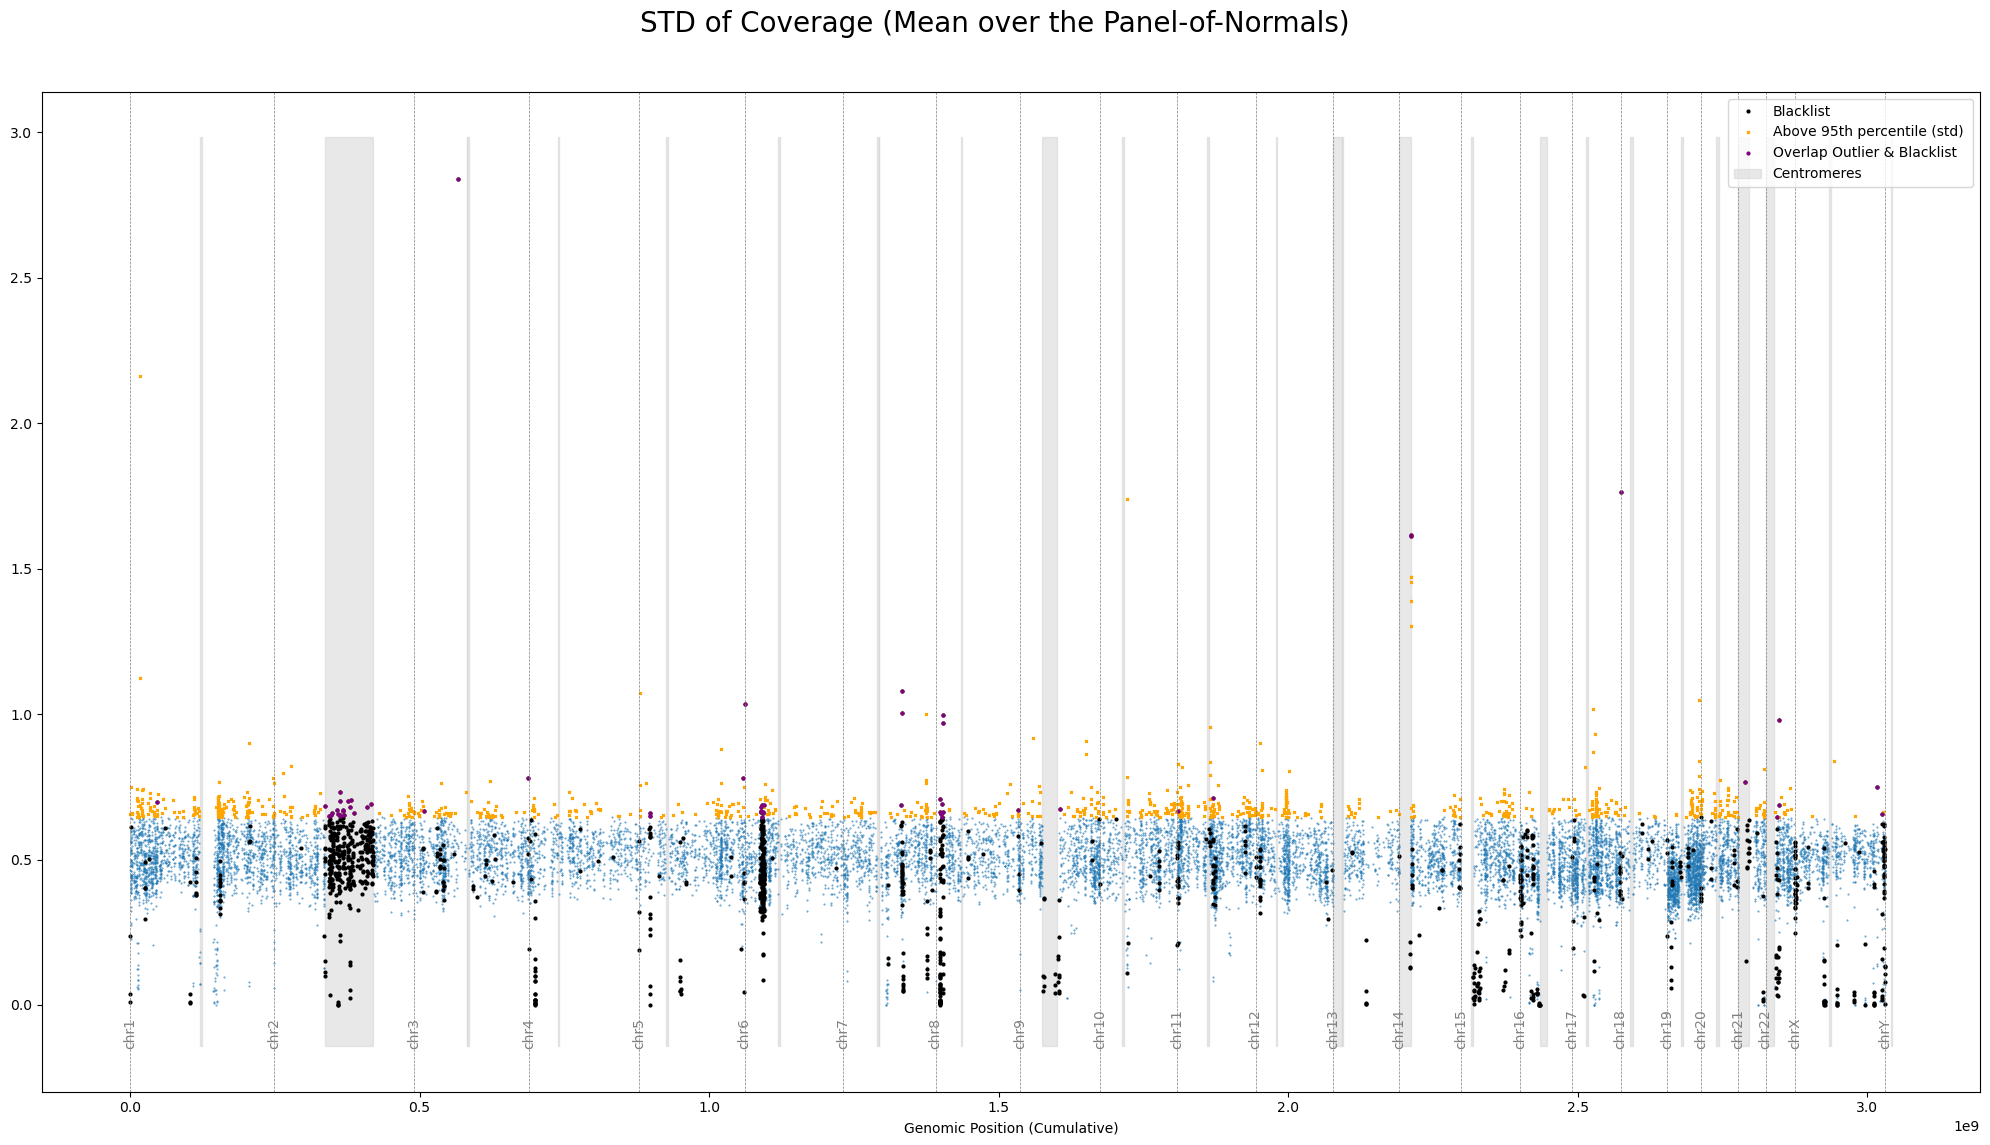

In [6]:
fig1 = plt.figure(figsize=(20, 12))
fig1.suptitle('STD of Coverage (Mean over the Panel-of-Normals)', fontsize=20)
# for i, (res, df) in enumerate(aggregated_data_gc.items()):
plt.plot(agg_pon['cumulative_pos'], agg_pon['mean_coverage_std'], linewidth=0.8, alpha=0.7, linestyle='', marker='.', markersize=1)

# Identify the hotspot
# 1. Define quantiles for the lower 2.5% and upper 2.5%
# lower_quantile = 0.025
upper_quantile = 0.95

# 2. Calculate the threshold values for both mean and std
# lower_threshold_mean = agg_pon['mean_coverage_mean'].quantile(lower_quantile)
# upper_threshold_mean = agg_pon['mean_coverage_mean'].quantile(upper_quantile)

upper_threshold_std = agg_pon['mean_coverage_std'].quantile(upper_quantile)

# 3. Identify indices for outliers (below the lower OR above the upper threshold)
# outlier_indices_mean = agg_pon[
#     (agg_pon['mean_coverage_mean'] <= lower_threshold_mean) | 
#     (agg_pon['mean_coverage_mean'] >= upper_threshold_mean)
# ].index

outlier_indices_std = agg_pon[
    (agg_pon['mean_coverage_std'] >= upper_threshold_std)
].index

# Find where both metrics are outliers
# overlap_indices = outlier_indices_mean.intersection(outlier_indices_std)

# print(f"Outlier thresholds (mean): {lower_threshold_mean:.4f} (lower) and {upper_threshold_mean:.4f} (upper)")
print(f"Outlier thresholds (std): {upper_threshold_std:.4f} (upper)")
# print(f"Number of outlier bins (mean): {len(outlier_indices_mean)}")
print(f"Number of outlier bins (std): {len(outlier_indices_std)}")
# print(f"Number of overlapping outlier bins: {len(overlap_indices)}")

# Is there overlap between outliers and blacklist?
std_blacklist_overlap_indices = np.intersect1d(blacklist_overlaps_indices, outlier_indices_std)
print(f"Number of overlapping outlier bins with blacklist: {len(std_blacklist_overlap_indices)}")

# 4. Highlight the outlier regions (updated variable names from hotspot to outlier)
plt.plot(agg_pon.loc[blacklist_overlaps_indices, 'cumulative_pos'], agg_pon.loc[blacklist_overlaps_indices, 'mean_coverage_std'], linestyle='', marker='o', color='black', markersize=2, label='Blacklist')
# plt.plot(agg_pon.loc[outlier_indices_mean, 'cumulative_pos'], agg_pon.loc[outlier_indices_mean, 'mean_coverage_std'], linestyle='', marker='o', color='red', markersize=2, label='Outlier (mean)')
plt.plot(agg_pon.loc[outlier_indices_std, 'cumulative_pos'], agg_pon.loc[outlier_indices_std, 'mean_coverage_std'], linestyle='', marker='x', color='orange', markersize=2, label=f'Above 95th percentile (std) ')
# plt.plot(agg_pon.loc[overlap_indices, 'cumulative_pos'], agg_pon.loc[overlap_indices, 'mean_coverage_std'], linestyle='', marker='*', color='purple', markersize=4, label='Outlier (overlap)')
plt.plot(agg_pon.loc[std_blacklist_overlap_indices, 'cumulative_pos'], agg_pon.loc[std_blacklist_overlap_indices, 'mean_coverage_std'], linestyle='', marker='o', color='purple', markersize=2, label='Overlap Outlier & Blacklist')


chr_sizes = get_hg38_chrom_lengths()
chr_labels = list(chr_sizes.keys())
ax_ylim = plt.ylim()
for offset_idx, offset in enumerate(chrom_offsets.values()):
    plt.axvline(offset, color='grey', ls='--', lw=0.5)
    # Add the chromosome labels
    if offset_idx < len(chr_labels):
        plt.text(offset, ax_ylim[0], chr_labels[offset_idx], color='grey', fontsize=10, ha='center', rotation=90)

# Colour in the centromeres
for _, row in blacklist.iterrows():
    centromere_chrom = row['chrom']
    centromere_start = row['start'] + chrom_offsets[centromere_chrom]
    centromere_end = row['end'] + chrom_offsets[centromere_chrom]
    plt.fill_betweenx(ax_ylim, centromere_start, centromere_end, color='lightgrey', alpha=0.5)

plt.xlabel('Genomic Position (Cumulative)')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
handles, labels = plt.gca().get_legend_handles_labels()
centromere_patch = mpatches.Patch(color='lightgrey', alpha=0.5, label='Centromeres')
handles.append(centromere_patch) 
plt.legend(handles=handles, loc='upper right')

plt.show()

# Save the indices to a file
all_removed_indices = np.unique(np.concatenate((blacklist_overlaps_indices, std_blacklist_overlap_indices)))
np.save("accessory_files/blacklist_and_std_outlier_indices.npy", all_removed_indices)

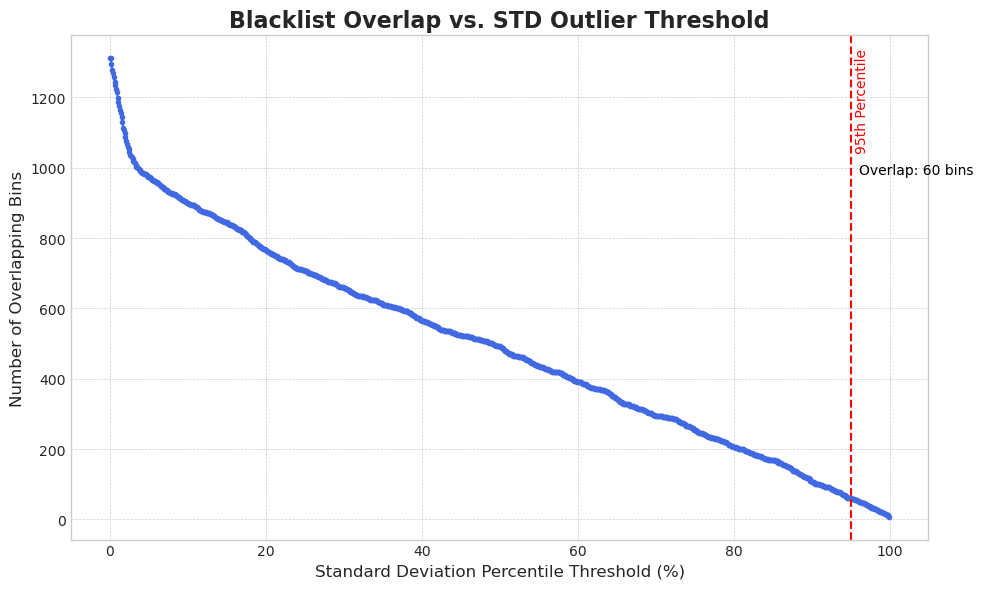

In [8]:
# 1. Define the range of percentiles to test
# We'll test from the 90th percentile up to the 99.9th
percentiles = np.arange(0, 1.0, 0.001)
overlap_counts = []

# 2. Loop through each percentile to calculate the overlap
for p in percentiles:
    # Calculate the STD threshold for the current percentile
    std_threshold = agg_pon['mean_coverage_std'].quantile(p)
    
    # Find outlier indices above this threshold
    outlier_indices = agg_pon[agg_pon['mean_coverage_std'] >= std_threshold].index
    
    # Find the intersection between outliers and the blacklist
    overlap = np.intersect1d(blacklist_overlaps_indices, outlier_indices)
    
    # Store the number of overlapping bins
    overlap_counts.append(len(overlap))

# overlap_counts = overlap_counts[::-1]

# 3. Create the plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# We multiply percentiles by 100 for a more readable x-axis (e.g., 95 instead of 0.95)
ax.plot(percentiles * 100, overlap_counts, marker='.', linestyle='-', color='royalblue')

ax.set_title('Blacklist Overlap vs. STD Outlier Threshold', fontsize=16, fontweight='bold')
ax.set_xlabel('Standard Deviation Percentile Threshold (%)', fontsize=12)
ax.set_ylabel('Number of Overlapping Bins', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add vertical line at 95 percentile indicating that the overlap there is 60
plt.axvline(95, color='red', linestyle='--', label='95th Percentile Threshold')
plt.text(95 + 0.5, max(overlap_counts)*0.8, '95th Percentile', color='red', fontsize=10, rotation=90)
plt.text(96, max(overlap_counts)*0.75, f'Overlap: {overlap_counts[950]} bins', color='black', fontsize=10)

plt.tight_layout()
plt.show()

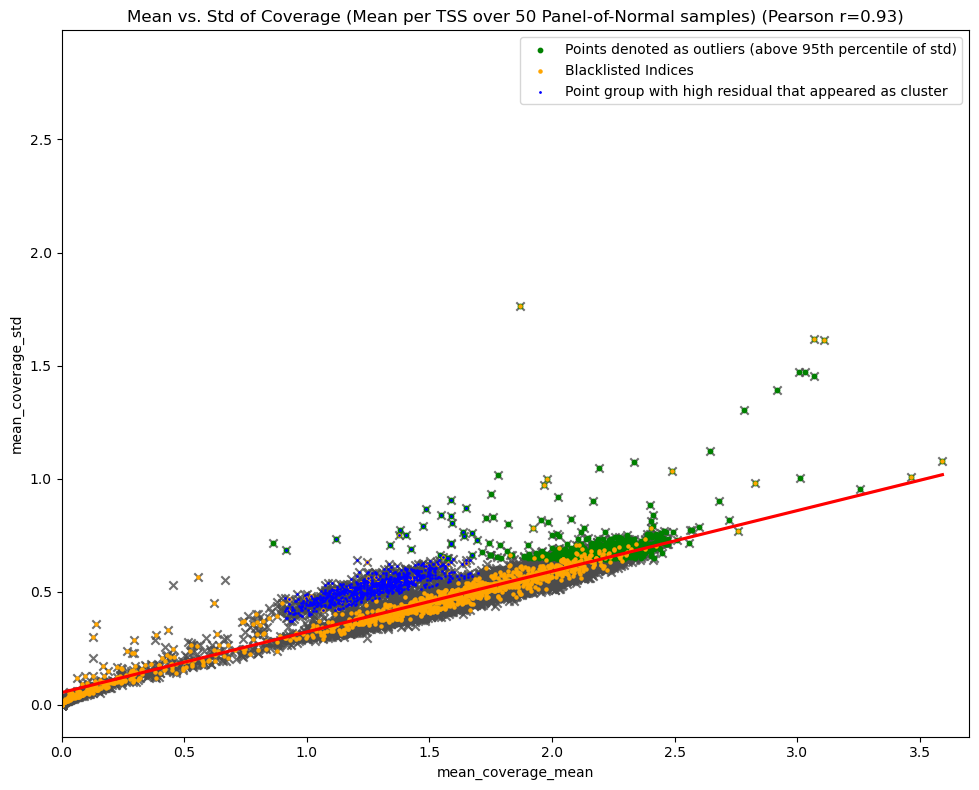

In [46]:
# What is the correlation between mean and std of coverage?
plt.figure(figsize=(10, 8))


# Calculate and display the Pearson correlation coefficient
pearson_corr = np.corrcoef(agg_pon['mean_coverage_mean'], agg_pon['mean_coverage_std'])[0, 1]
plt.title(f'Mean vs. Std of Coverage (Mean per TSS over 50 Panel-of-Normal samples) (Pearson r={pearson_corr:.2f})')
plt.xlabel('Mean Coverage')
plt.ylabel('Std of Coverage')
plt.tight_layout()

# Select the 3 points with the highest mean
top3_mean_indices = agg_pon['mean_coverage_mean'].nlargest(3).index
# Create a list of the indices without the top 3 mean indices to avoid highlighting them
without_top3_indices = agg_pon.index.difference(top3_mean_indices)

sns.regplot(
    x=agg_pon['mean_coverage_mean'].iloc[without_top3_indices], y=agg_pon['mean_coverage_std'].iloc[without_top3_indices],
    ci=99, marker="x", color=".3", line_kws=dict(color="r"),
)

# Calculate the distance from the regression line for each point
# Correct: Call the function with its arguments
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(
    agg_pon['mean_coverage_mean'], agg_pon['mean_coverage_std']
)
predicted_std = intercept + slope * agg_pon['mean_coverage_mean']
residual = agg_pon['mean_coverage_std'] - predicted_std
# Find the 95th percentile of the residuals
residual_95th = np.percentile(residual, 95)

# Find the points in the range of mean coverage 0.9 to 1.7 and highlight them.
in_range_indices = agg_pon[(agg_pon['mean_coverage_mean'] >= 0.9) & (agg_pon['mean_coverage_mean'] <= 1.7)].index
# Sort in_range_indices by residual
in_range_indices = in_range_indices[residual[in_range_indices] > residual_95th]

# Find the points of the in_range_indices that also have a high residual (above 95th percentile of std)
highlight_indices = in_range_indices.intersection(outlier_indices_std)

plt.scatter(
    agg_pon.loc[outlier_indices_std, 'mean_coverage_mean'],
    agg_pon.loc[outlier_indices_std, 'mean_coverage_std'],
    color='green', s=10, label='Points denoted as outliers (above 95th percentile of std)'
)

plt.scatter(
    agg_pon['mean_coverage_mean'].iloc[blacklist_overlaps_indices],
    agg_pon['mean_coverage_std'].iloc[blacklist_overlaps_indices],
    color='orange', s=5, label='Blacklisted Indices'
)

plt.scatter(
    agg_pon['mean_coverage_mean'].iloc[in_range_indices],
    agg_pon['mean_coverage_std'].iloc[in_range_indices],
    color='blue', s=1, label='Point group with high residual that appeared as cluster'
)

plt.xlim(0, 3.7)
plt.legend()
plt.show()

# # Plot the distribution of std of coverage
# plt.figure(figsize=(8, 6))
# sns.histplot(agg_pon['mean_coverage_std'], bins=1000)
# sns.histplot(agg_pon['mean_coverage_std'].iloc[outlier_indices_std], bins=1000, color='orange', label=f'Above 95th percentile (n={len(outlier_indices_std)})')
# plt.title('Distribution of Std of Coverage Across Bins')
# plt.xlabel('Std of Coverage')
# plt.ylabel('Frequency')
# plt.tight_layout()
# plt.legend()
# plt.show()

# plt.figure(figsize=(8, 6))
# sns.histplot(feature_arrays_pon['mean_coverage'][:1, :], bins=30, kde=False)
# # sns.histplot(agg_pon['mean_coverage_std'].iloc[outlier_indices_std], bins=100, kde=True, color='orange')
# plt.title('Distribution of Std of Coverage Across Bins')
# plt.xlabel('Std of Coverage')
# plt.ylabel('Frequency')
# plt.tight_layout()
# plt.show()

Comparison of Attributes Between Selected Group and Background
                              attribute            test        p_value  \
0                                 chrom     Chi-squared   0.000000e+00   
1              mean_coverage_short_mean  Mann-Whitney U   0.000000e+00   
2         absolute_short_fragments_mean  Mann-Whitney U   0.000000e+00   
3          relative_fragment_counts_std  Mann-Whitney U   0.000000e+00   
4                        cumulative_pos  Mann-Whitney U   0.000000e+00   
5         absolute_fragment_counts_mean  Mann-Whitney U  8.725178e-283   
6                    mean_coverage_mean  Mann-Whitney U  1.427090e-263   
7         relative_fragment_counts_mean  Mann-Whitney U  5.814810e-245   
8                  coverage_spread_mean  Mann-Whitney U  9.218536e-240   
9          absolute_long_fragments_mean  Mann-Whitney U  5.772310e-220   
10              mean_coverage_long_mean  Mann-Whitney U  1.796821e-209   
11                   fslr_coverage_mean  Mann-Whi

<Figure size 800x500 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

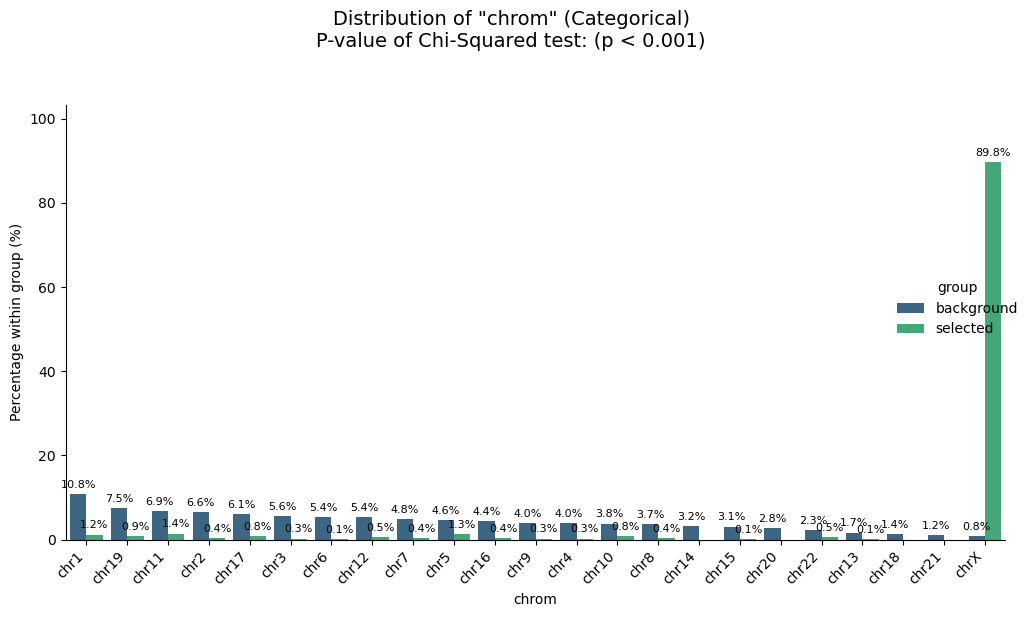

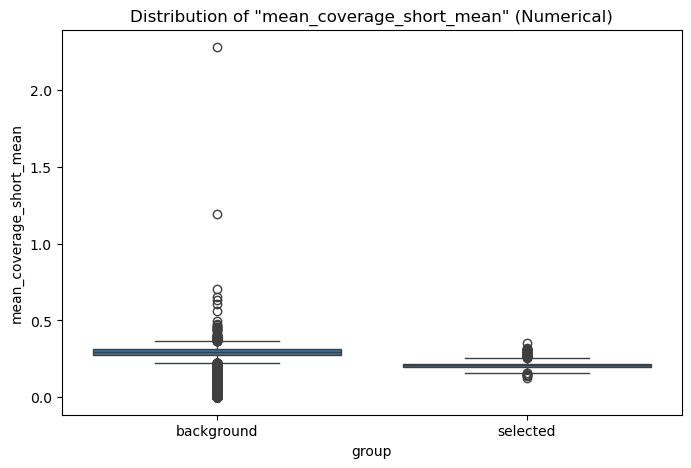

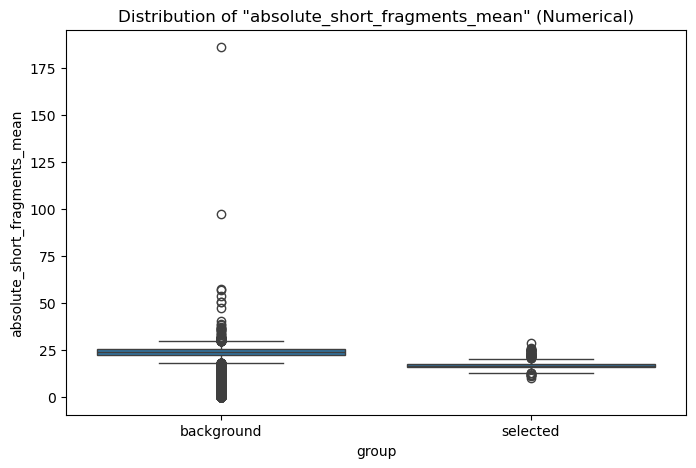

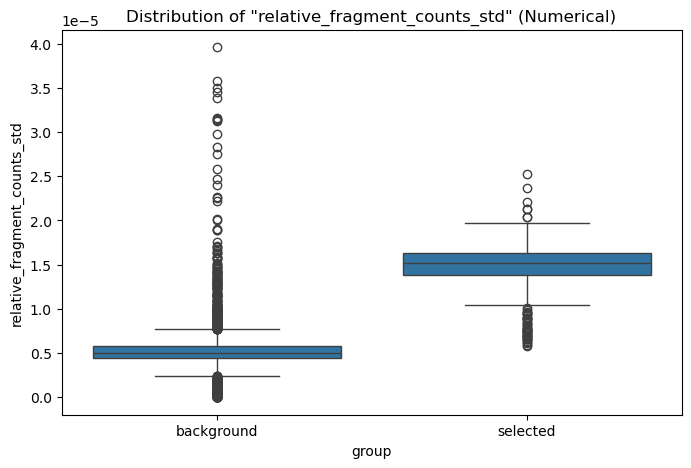

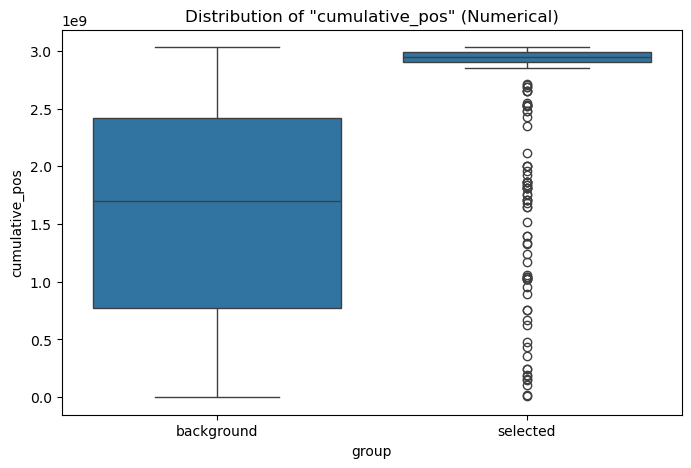

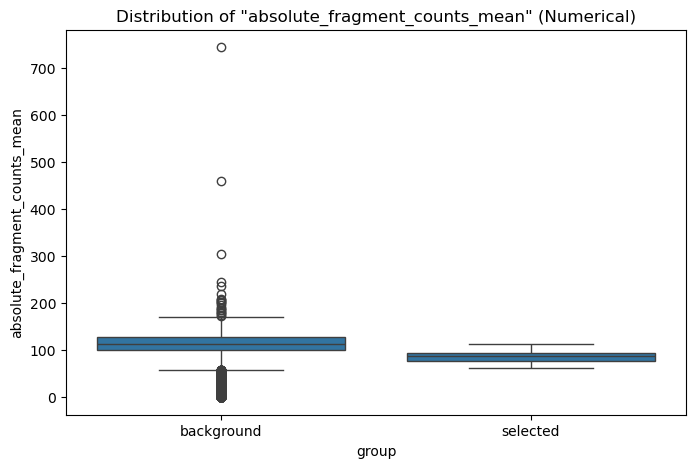

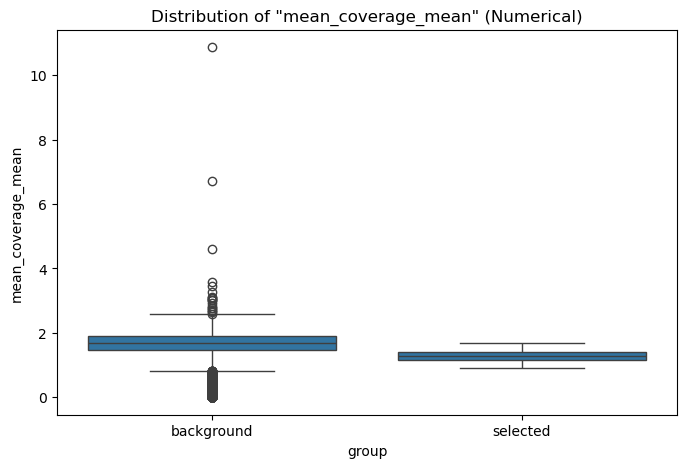

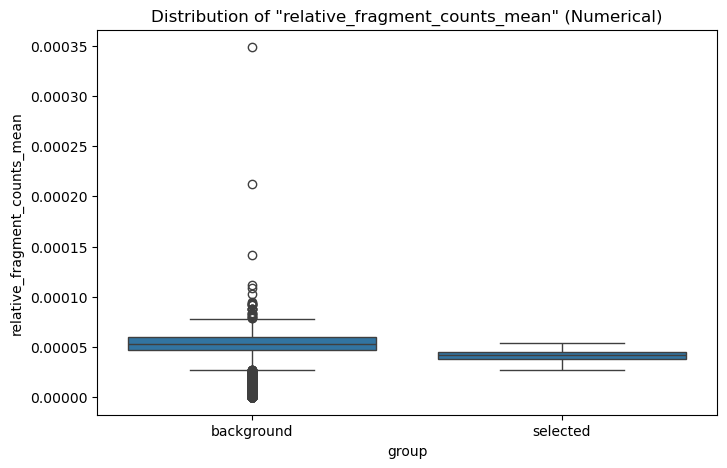

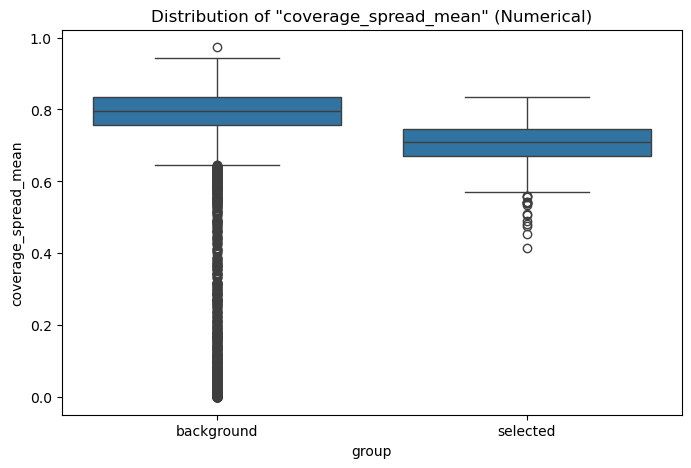

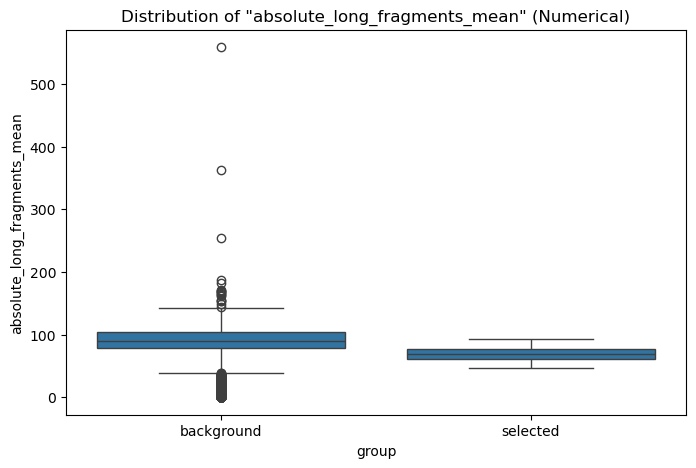

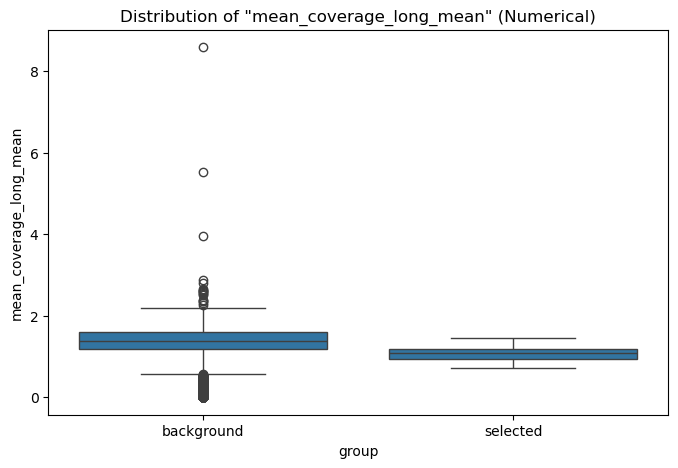

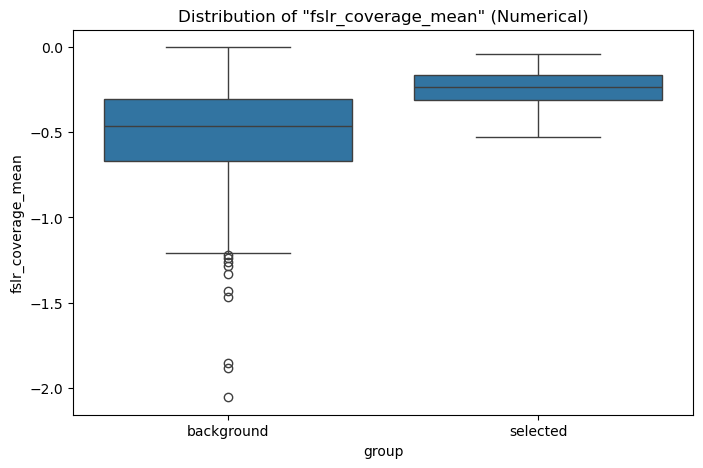

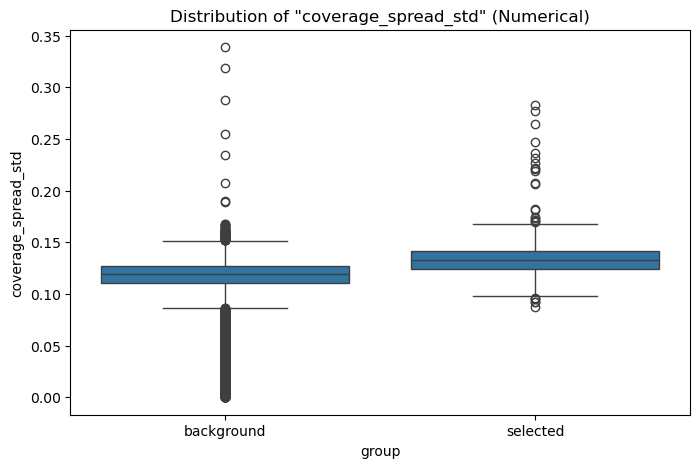

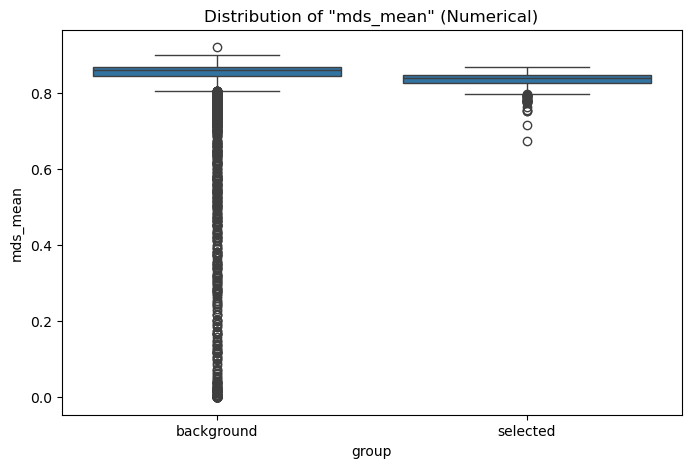

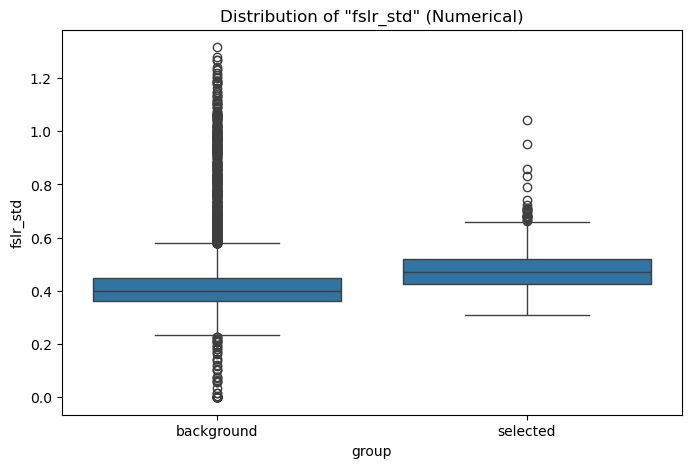

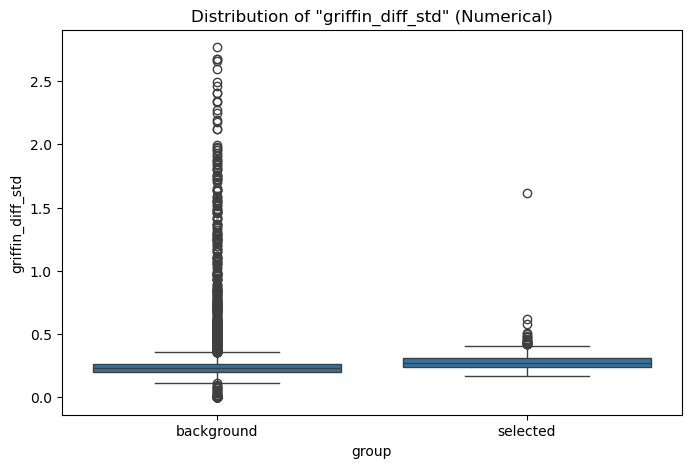

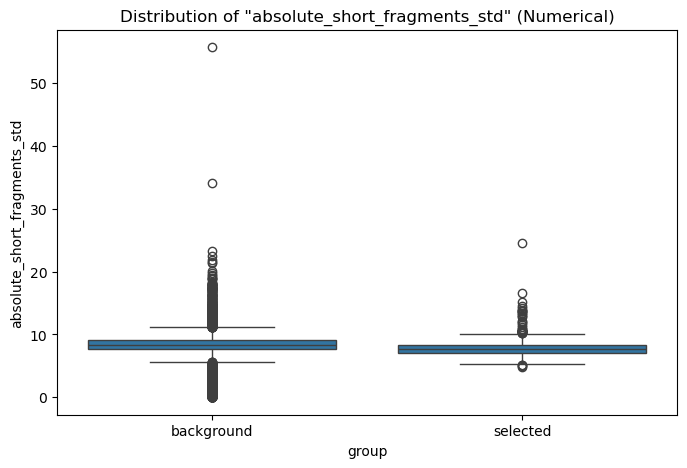

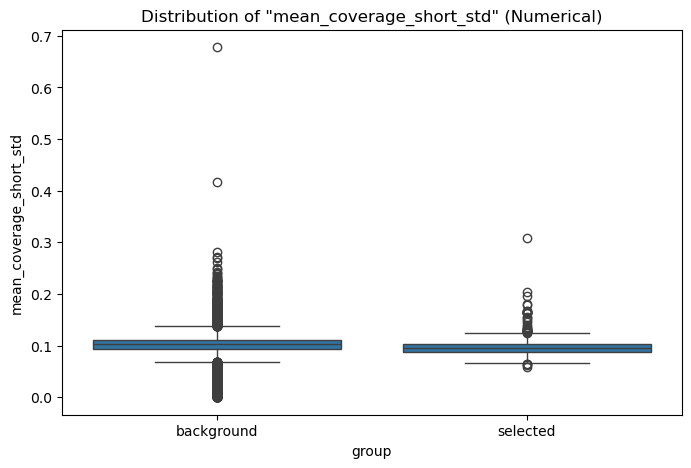

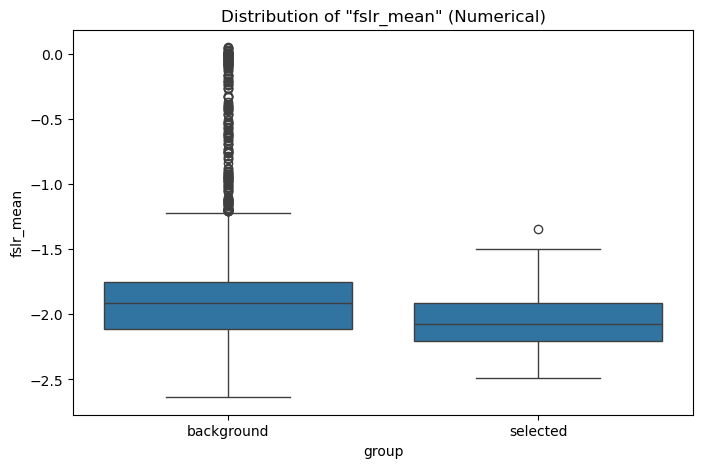

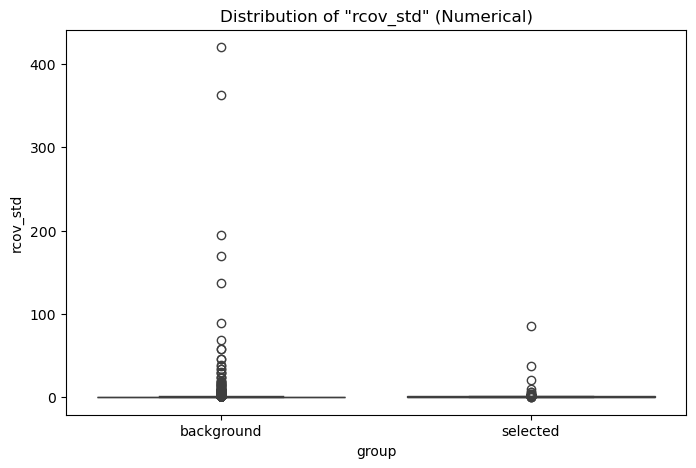

In [54]:
from scipy.stats import mannwhitneyu, chi2_contingency

# Add a 'group' column for easy comparison
agg_pon['group'] = 'background'
agg_pon.loc[in_range_indices, 'group'] = 'selected'


# --- 2. PERFORM STATISTICAL TESTS ---
results = []
# Separate the two groups for testing
selected_group = agg_pon[agg_pon['group'] == 'selected']
background_group = agg_pon[agg_pon['group'] == 'background']


# Iterate over all columns except our new 'group' column
for col in agg_pon.columns.drop('group'):
    col_type = agg_pon[col].dtype

    # A. For NUMERICAL columns
    if np.issubdtype(col_type, np.number):
        # Skip columns with no variance
        if agg_pon[col].nunique() <= 1:
            continue
        
        stat, p_value = mannwhitneyu(
            selected_group[col].dropna(),
            background_group[col].dropna()
        )
        
        results.append({
            'attribute': col,
            'test': 'Mann-Whitney U',
            'p_value': p_value,
            'selected_median': selected_group[col].median(),
            'background_median': background_group[col].median()
        })

    # B. For CATEGORICAL columns
    elif col_type == 'object':
        # Skip columns with no variance
        if agg_pon[col].nunique() <= 1:
            continue

        contingency_table = pd.crosstab(agg_pon['group'], agg_pon[col])
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        
        results.append({
            'attribute': col,
            'test': 'Chi-squared',
            'p_value': p_value,
            'selected_median': selected_group[col].mode().iloc[0], # Using mode for categorical
            'background_median': background_group[col].mode().iloc[0]
        })

# --- 3. CREATE AND DISPLAY THE SUMMARY TABLE ---
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='p_value').reset_index(drop=True)

print("Comparison of Attributes Between Selected Group and Background")
print(summary_df)


# --- 4. VISUALIZE THE TOP DIFFERENCES ---
top_n = min(20, len(summary_df)) # Plot top 3 or fewer if less results
print(f"\n--- Visualizing the top {top_n} most significant differences ---")

for i in range(top_n):
    top_attribute = summary_df.loc[i, 'attribute']
    test_type = summary_df.loc[i, 'test']
    p_value = summary_df.loc[i, 'p_value']
    
    # Format p-value for display
    p_value_str = f"p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
    
    plt.figure(figsize=(8, 5))
    
    if test_type == 'Mann-Whitney U':
        sns.boxplot(data=agg_pon, x='group', y=top_attribute, order=['background', 'selected'])
        plt.title(f'Distribution of "{top_attribute}" (Numerical)')
    
    else: # Chi-squared test
        plt.figure(figsize=(10, 6)) # Increased figure size for bar plots

        # Calculate percentages within each group
        plot_df = agg_pon.groupby('group')[top_attribute].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

        # Use seaborn.catplot for better visualization of proportions across groups
        g = sns.catplot(
            data=plot_df, x=top_attribute, y='percentage', hue='group', kind='bar',
            height=6, aspect=1.5, palette='viridis' # Adjust height and aspect as needed
        )
        g.fig.suptitle(f'Distribution of "{top_attribute}" (Categorical)\nP-value of Chi-Squared test: ({p_value_str})', y=1.02, fontsize=14) # Title for the entire figure
        g.set_axis_labels(top_attribute, 'Percentage within group (%)')
        g.set_xticklabels(rotation=45, ha='right') # Rotate x-axis labels if many categories

        # Add percentage labels on top of bars
        for ax in g.axes.flat:
            for c in ax.containers:
                labels = [f'{v.get_height():.1f}%' for v in c]
                ax.bar_label(c, labels=labels, label_type='edge', fontsize=8, padding=3)
            ax.margins(y=0.15) # Adjust y-margin to make space for labels

        plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
        plt.show()

In [31]:
summary_df

,attribute,test,p_value,selected_median,background_median
0,chrom,Chi-squared,0.000000e+00,chrX,chr1
1,mean_coverage_short_mean,Mann-Whitney U,0.000000e+00,0.206918,0.296911
2,absolute_short_fragments_mean,Mann-Whitney U,0.000000e+00,16.749403,24.079749
3,relative_fragment_counts_std,Mann-Whitney U,0.000000e+00,0.000015,0.000005
4,cumulative_pos,Mann-Whitney U,0.000000e+00,2945286126.0,1698317204.0
5,absolute_fragment_counts_mean,Mann-Whitney U,8.725178e-283,86.78756,114.072462
6,mean_coverage_mean,Mann-Whitney U,1.427090e-263,1.287724,1.677308
7,relative_fragment_counts_mean,Mann-Whitney U,5.814810e-245,0.000042,0.000053
8,coverage_spread_mean,Mann-Whitney U,9.218536e-240,0.708776,0.79677
9,absolute_long_fragments_mean,Mann-Whitney U,5.772310e-220,69.758462,89.608618


In [10]:
def normalize_feature_arrays(feature_dict: dict) -> dict:
    """
    Performs row-wise Z-score normalization on a dictionary of feature arrays.
    
    Safely handles rows with a standard deviation of zero to prevent runtime warnings.
    """
    normalized_dict = {}
    for feature, array in feature_dict.items():
        # Calculate mean and standard deviation, ignoring NaNs
        row_means = np.nanmean(array, axis=1, keepdims=True)
        row_stds = np.nanstd(array, axis=1, keepdims=True)
        
        # Replace any standard deviation of 0 with 1.
        row_stds[row_stds == 0] = 1
        
        # Perform the normalization
        normalized_array = (array - row_means) / row_stds
        
        # Replace any resulting NaNs (from rows that were all NaN) with 0
        normalized_dict[feature] = np.nan_to_num(normalized_array)
        
        print(f"Normalized feature '{feature}' with shape {array.shape} to shape {normalized_dict[feature].shape}")
        
    return normalized_dict

# --- Apply the function to all your data dictionaries ---
feature_arrays_pon_normalized = normalize_feature_arrays(feature_arrays_pon)
feature_arrays_healthy_normalized = normalize_feature_arrays(feature_arrays_healthy)
feature_arrays_cancer_normalized = normalize_feature_arrays(feature_arrays_cancer)


Normalized feature 'gc_content' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'fslr' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'fslr_coverage' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'griffin_diff' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'rcov' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'mwh' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'mean_coverage' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'absolute_fragment_counts' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'coverage_spread' with shape (48, 19376) to shape (48, 19376)
Normalized feature 'gc_content' with shape (212, 19376) to shape (212, 19376)
Normalized feature 'fslr' with shape (212, 19376) to shape (212, 19376)
Normalized feature 'fslr_coverage' with shape (212, 19376) to shape (212, 19376)
Normalized feature 'griffin_diff' with shape (212, 19376) to shape (212, 1937


Processing feature: FSLR
  Calculating correlations for Age at Diagnosis (Inlier)...


  0%|          | 0/17156 [00:00<?, ?it/s]

  6%|▌         | 989/17156 [00:01<00:18, 877.42it/s] /tmp/ipykernel_48383/3008427772.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = scipy.stats.spearmanr(
100%|██████████| 17156/17156 [00:23<00:00, 731.98it/s] 


  Calculating correlations for Age at Diagnosis (Blacklist)...


100%|██████████| 1311/1311 [00:00<00:00, 8948.99it/s]


...

100%|██████████| 17156/17156 [00:04<00:00, 3522.19it/s]


  Calculating correlations for cfDNA Input (ng/ml) (Blacklist)...


100%|██████████| 1311/1311 [00:00<00:00, 3315.41it/s]


  Calculating correlations for cfDNA Input (ng/ml) (STD Outlier)...


100%|██████████| 909/909 [00:00<00:00, 3403.53it/s]


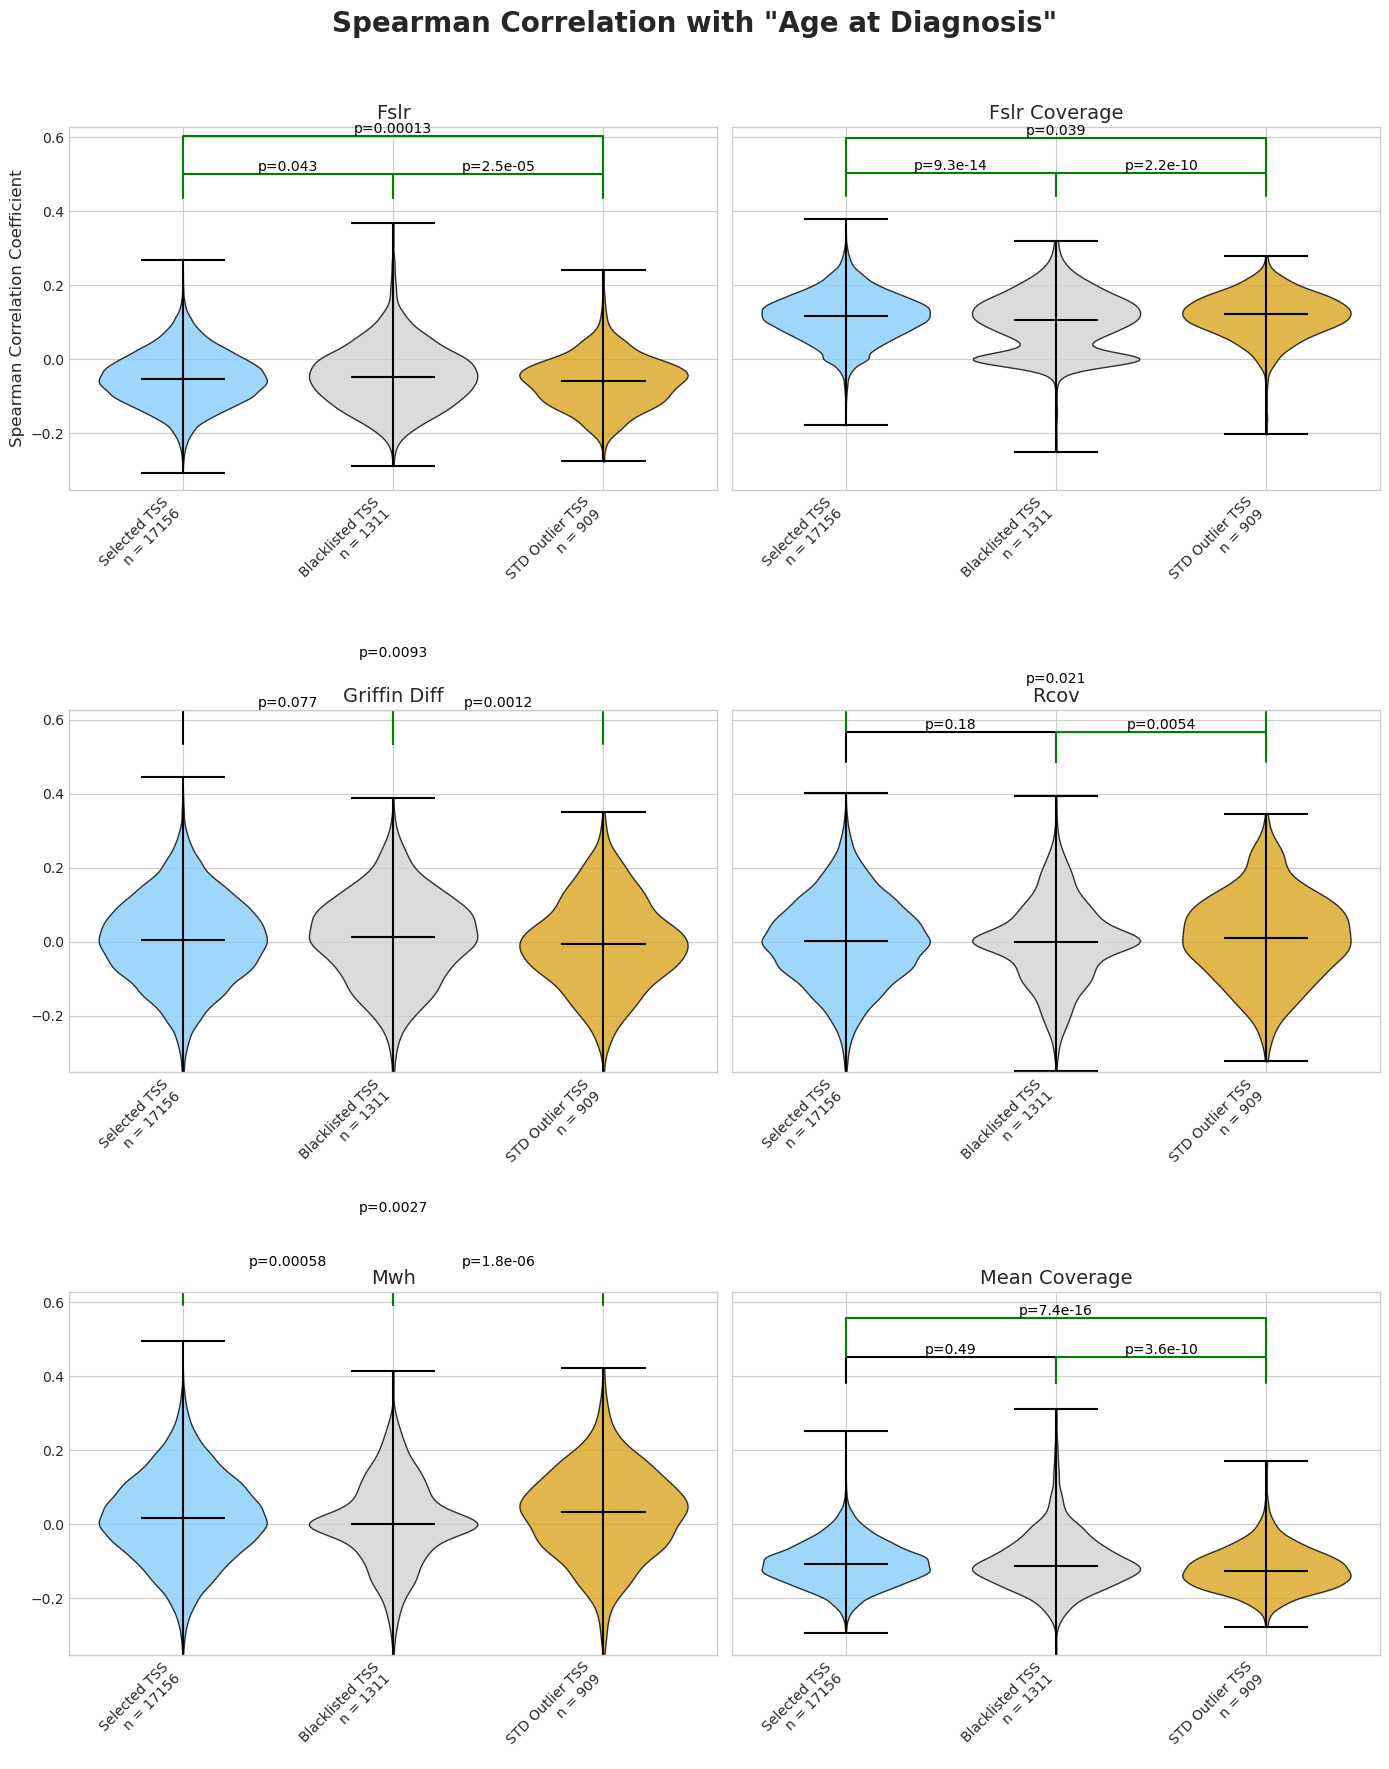

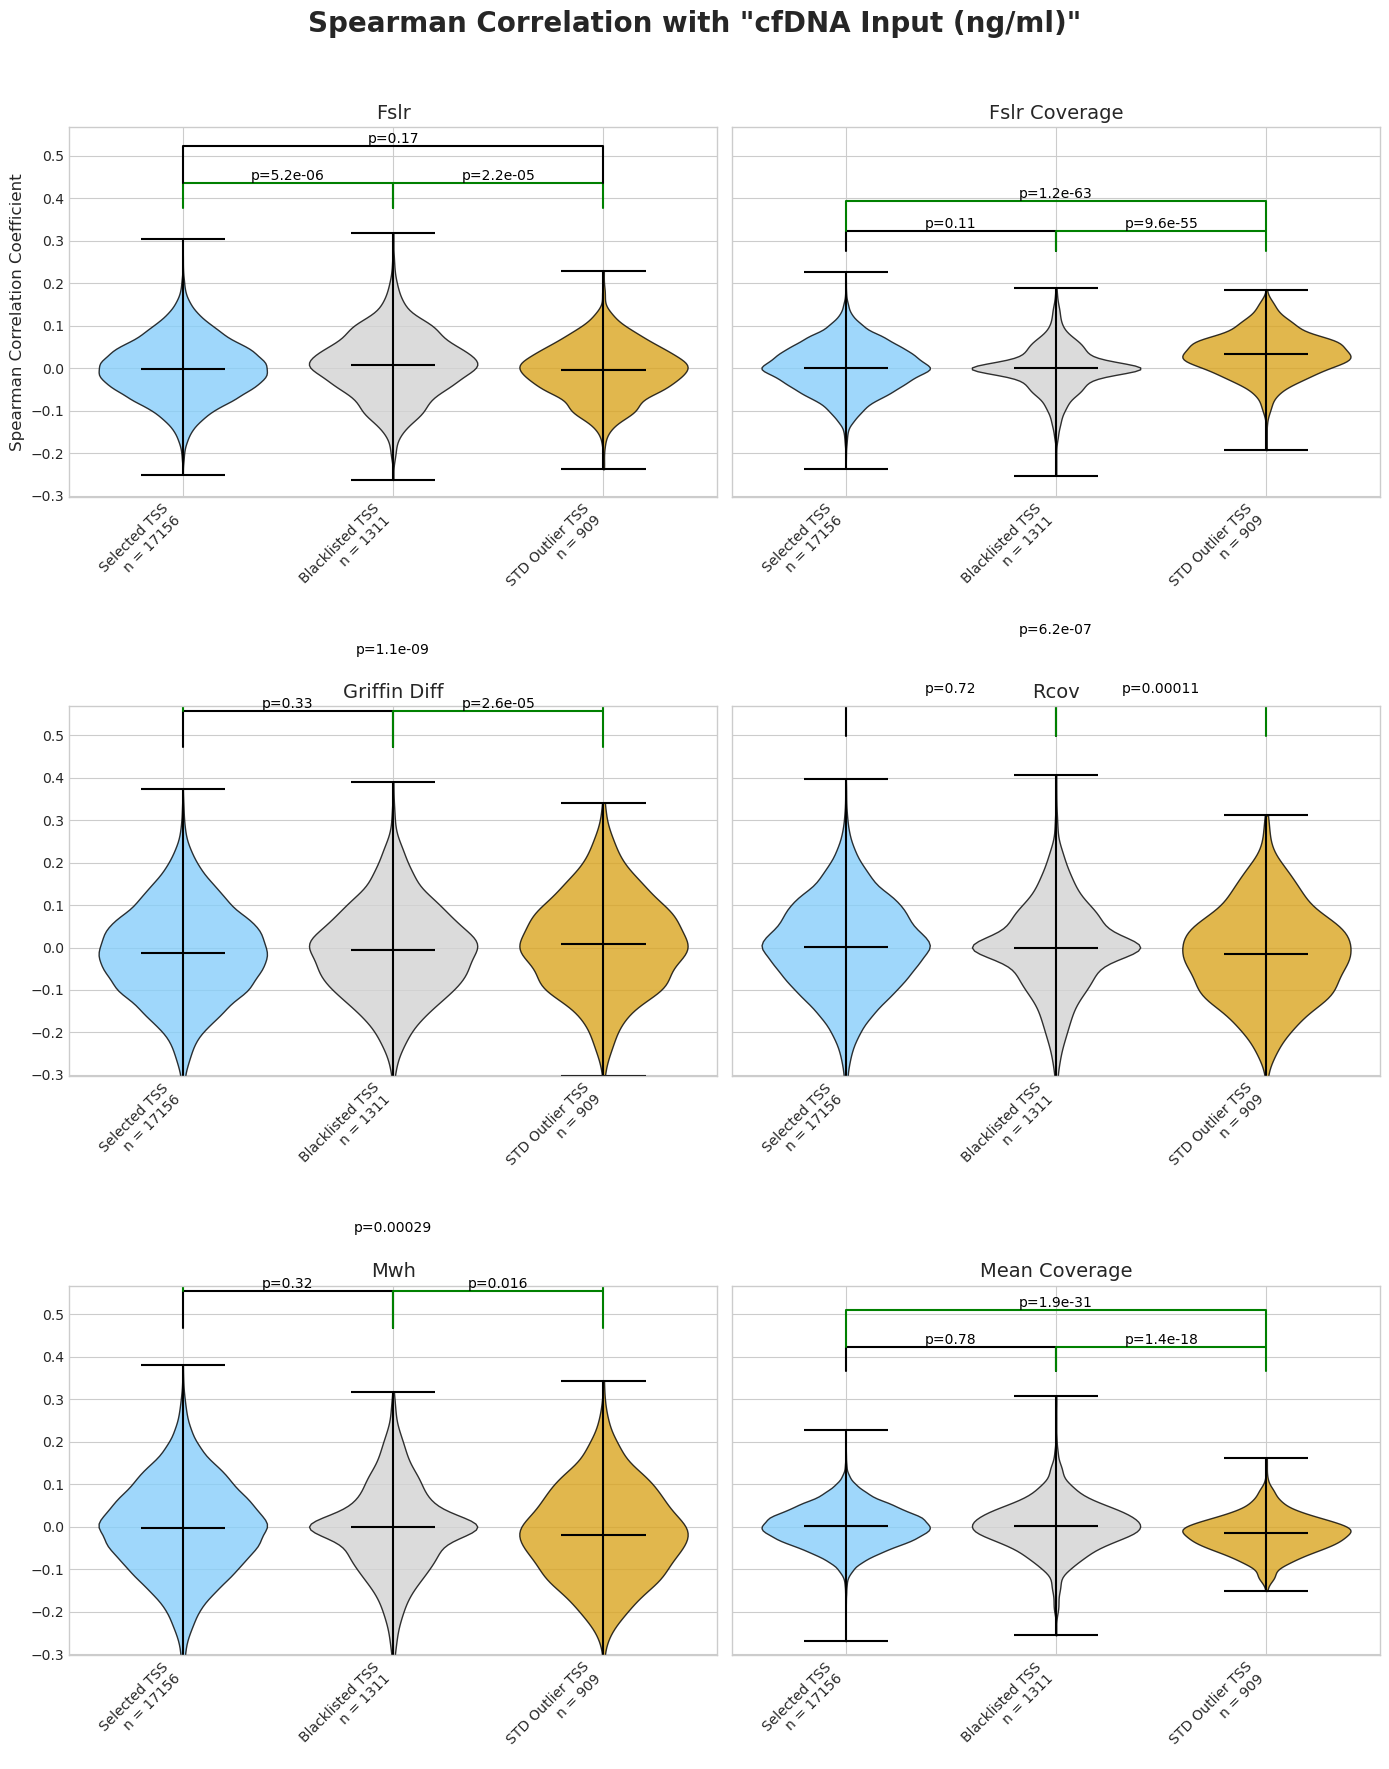

In [11]:
blacklist_indices = blacklist_overlaps_indices
outlier_indices = np.setdiff1d(outlier_indices_std, blacklist_indices)
temp_indices = np.union1d(outlier_indices, blacklist_indices)
inlier_indices = np.setdiff1d(agg_pon.index, temp_indices)

# --- **CHANGE 1**: Define the features and confounders you want to analyze ---
features_to_test = [ "fslr", "fslr_coverage", "griffin_diff", "rcov", "mwh", "mean_coverage"]
confounders = ['Age at Diagnosis', 'cfDNA Input (ng/ml)']
groups = {
    'Inlier': inlier_indices,
    'Blacklist': blacklist_indices,
    'STD Outlier': outlier_indices
}

# --- **CHANGE 2**: Update the calculation loop to handle multiple features ---
# The dictionary will now be nested as: feature -> confounder -> group
spearman_dict = {feature: {} for feature in features_to_test}

for feature in features_to_test:
    print(f"\nProcessing feature: {feature.upper()}")
    for confounder in confounders:
        spearman_dict[feature][confounder] = {}
        for group_name, indices in groups.items():
            print(f"  Calculating correlations for {confounder} ({group_name})...")
            correlations = np.zeros(len(indices))
            for i, idx in enumerate(tqdm(indices)):
                corr, _ = scipy.stats.spearmanr(
                    feature_arrays_cancer[feature][:, idx],
                    cris_supplement_cancer.get(confounder), nan_policy='omit'
                )
                correlations[i] = corr
            spearman_dict[feature][confounder][group_name] = np.nan_to_num(correlations, nan=0.0)


# --- **UPDATED PLOTTING LOOP** ---
for confounder in confounders:
    num_features = len(features_to_test)
    
    # **CHANGE 1: Calculate grid dimensions**
    # Set the number of columns you want
    ncols = 2
    # Calculate the number of rows needed to fit all features
    nrows = (num_features + ncols - 1) // ncols  # This is a ceiling division
    
    # **CHANGE 2: Create a subplot grid with the calculated dimensions**
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7 * ncols, 6 * nrows), # Adjust figsize for a grid
        sharey=True  # All subplots will share the same y-axis
    )
    
    # **CHANGE 3: Flatten the axes array for easy iteration**
    # This converts the 2D array of axes into a 1D list
    axes = axes.flatten()
        
    fig.suptitle(f'Spearman Correlation with "{confounder}"', fontsize=20, fontweight='bold')

    # Loop through each feature and its corresponding subplot
    for i, feature in enumerate(features_to_test):
        ax = axes[i] # Get the current axis
        ax.set_title(feature.replace('_', ' ').title(), fontsize=14)
        
        data_to_plot = [
            spearman_dict[feature][confounder]['Inlier'],
            spearman_dict[feature][confounder]['Blacklist'],
            spearman_dict[feature][confounder]['STD Outlier']
        ]
        labels = [f'Selected TSS\nn = {len(inlier_indices)}', f'Blacklisted TSS\nn = {len(blacklist_indices)}', f'STD Outlier TSS\nn = {len(outlier_indices)}']
        colors = ['lightskyblue', 'lightgrey', 'goldenrod']
        
        vp = ax.violinplot(data_to_plot, showmedians=True, widths=0.8)
        
        # Color the violins
        for k, body in enumerate(vp['bodies']):
            body.set_facecolor(colors[k])
            body.set_edgecolor('black')
            body.set_alpha(0.8)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp[partname].set_edgecolor('black')
            vp[partname].set_linewidth(1.5)

        # --- Statistical Annotations for the subplot ---
        # (This part of your code remains the same)
        y_max = np.concatenate(data_to_plot).max()
        y_min = np.concatenate(data_to_plot).min()
        y_range = y_max - y_min if y_max > y_min else 1
        
        h1 = y_max + y_range * 0.1
        h2 = y_max + y_range * 0.2
        h3 = y_max + y_range * 0.35

        p1 = scipy.stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided').pvalue
        ax.plot([1, 1, 2, 2], [h1, h2, h2, h1], lw=1.5, c='green' if p1 < 0.05 else 'black')
        ax.text(1.5, h2, f"p={p1:.2g}", ha='center', va='bottom', color='black')

        p2 = scipy.stats.mannwhitneyu(data_to_plot[1], data_to_plot[2], alternative='two-sided').pvalue
        ax.plot([2, 2, 3, 3], [h1, h2, h2, h1], lw=1.5, c='green' if p2 < 0.05 else 'black')
        ax.text(2.5, h2, f"p={p2:.2g}", ha='center', va='bottom', color='black')

        p3 = scipy.stats.mannwhitneyu(data_to_plot[0], data_to_plot[2], alternative='two-sided').pvalue
        ax.plot([1, 1, 3, 3], [h2, h3, h3, h2], lw=1.5, c='green' if p3 < 0.05 else 'black')
        ax.text(2, h3, f"p={p3:.2g}", ha='center', va='bottom', color='black')

        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylim(top=h3 + y_range * 0.1)

    # **CHANGE 4: Hide any unused subplots**
    # If you have an odd number of features, the last subplot will be empty
    for i in range(num_features, len(axes)):
        axes[i].set_visible(False)

    # Set a single y-label for the whole figure (on the first subplot)
    if num_features > 0:
      axes[0].set_ylabel('Spearman Correlation Coefficient', fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
    plt.show()
